# Objectives
Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
1. Diabetes Classification (Y/N)
2. Feature importance and explainability
3. Early diabetes risk prediction
4. Clustering for risk group 


# Libraries and dependencies

In [340]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 162.5 kB/s eta 0:10:26
   ---------------------------------------- 0.0/101.7 MB 245.8 kB/s eta 0:06:54
   ---------------------------------------- 0.1/101.7 MB 535.8 kB/s eta 0:03:10
   ---------------------------------------- 0.2/101.7 MB 888.4 kB/s eta 0:01:55
   ---------------------------------------- 0.3/101.7 MB 1.1 MB/s eta 0:01:29
   ---------------------------------------- 0.4/101.7 MB 1.3 MB/s eta 0:01:16
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:07
   ---------------------------------------- 0.6/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 0.7/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 0.8/101.7 MB 1.7 MB/s eta 0:00:59


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt


# Load dataset

In [318]:
# Define the path correctly
dataset_path = "data/diabetes.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(dataset_path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [319]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [321]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [322]:
# Distribution of the 2 classes in Outcome column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

In [323]:
# List of continuous numerical columns
X = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [324]:
def plot_histograms(df, columns, title='Histograms for Numerical Columns'):
    """
    Plots histograms for the specified numerical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): List of numerical column names to plot.
        title (str): Title for the entire figure.
    """
    num_cols = len(columns)
    n_rows = (num_cols // 3) + (num_cols % 3 > 0)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        axes[i].hist(df[column].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(column)
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


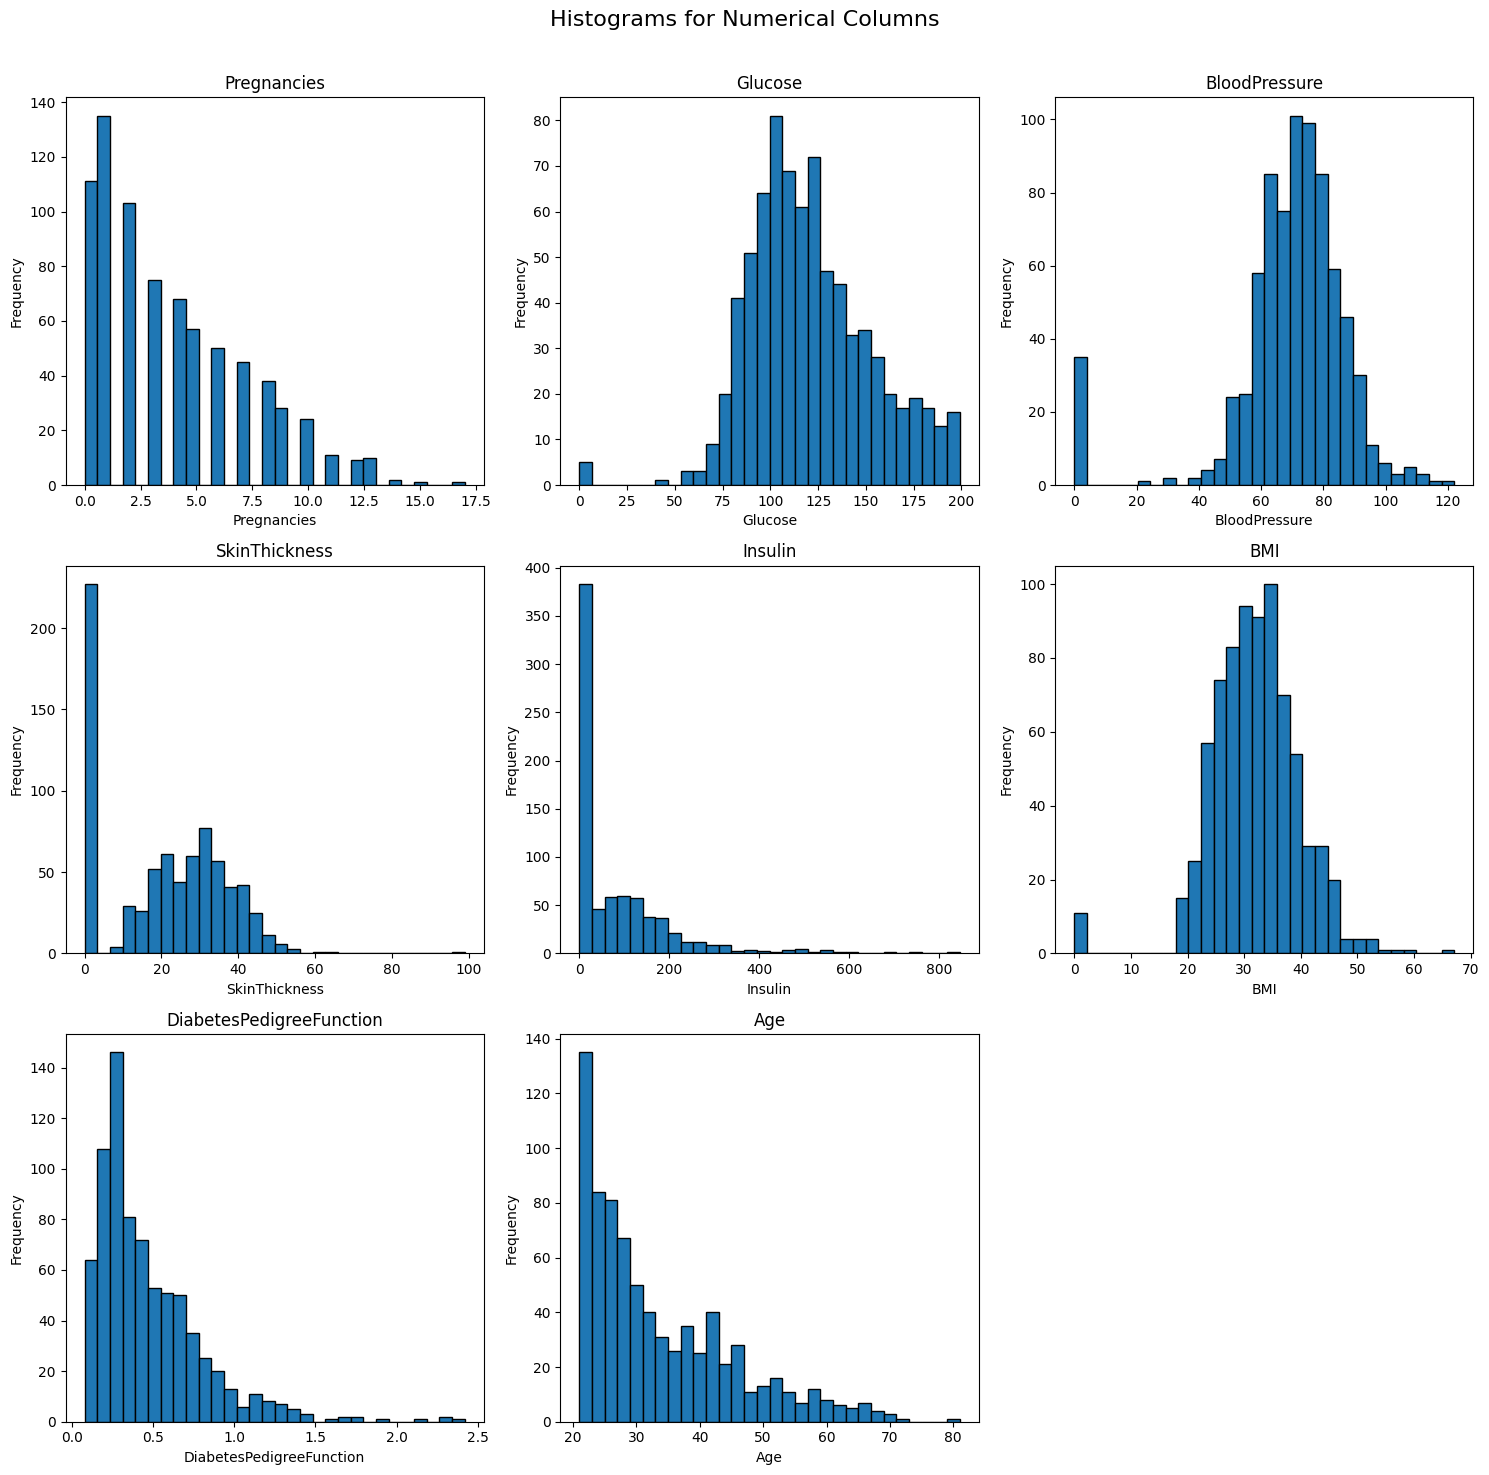

In [325]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Replace 0 in appropriate columns with median

In [327]:
# List of columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN first
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Impute NaNs with median based on Outcome (0 = non-diabetic, 1 = diabetic)
for col in invalid_zero_cols:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))


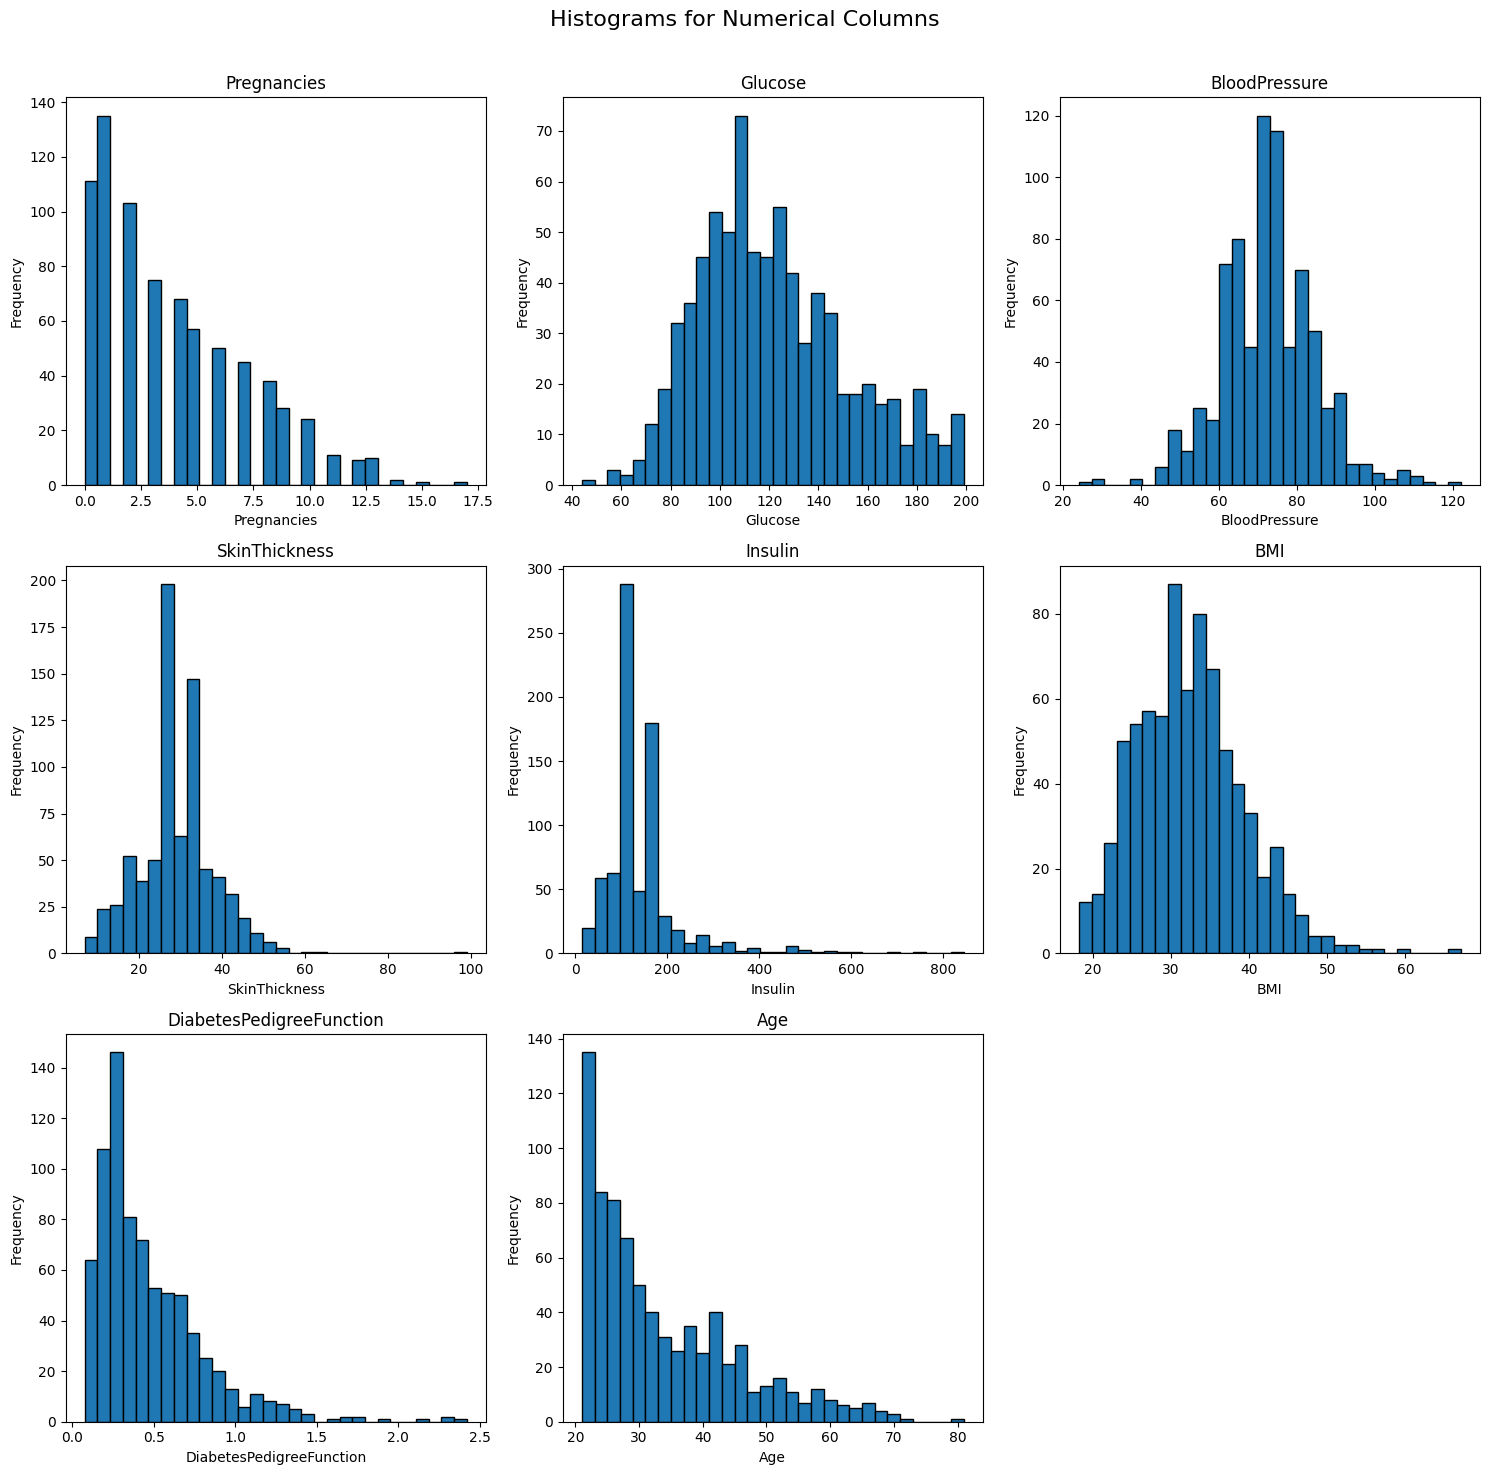

In [328]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Skewness of features

In [ ]:
# 📊 Print skewness for each numerical column in your DataFrame
print("📈 Skewness of each column:\n")
print(df[X].skew().sort_values(ascending=False))

📈 Skewness of each column:

Insulin                     3.028046
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.817477
BMI                         0.606416
Glucose                     0.532324
BloodPressure               0.140830
dtype: float64


# Remove outliers using z-score and IQR

In [330]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Columns for IQR filtering
iqr_cols = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'Age']

# Columns for Z-score filtering (the rest of X)
zscore_cols = [col for col in X if col not in iqr_cols]

# --- IQR Filtering ---
iqr_mask = pd.Series([True] * len(df))
for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_mask &= df[col].between(lower, upper)

# --- Z-score Filtering ---
z_scores = np.abs(zscore(df[zscore_cols]))
zscore_mask = (z_scores <= 3).all(axis=1)

# --- Combined Mask ---
combined_mask = iqr_mask & zscore_mask

# Apply the combined mask
df_no_outliers = df[combined_mask].reset_index(drop=True)

print(f"✅ Outliers removed: {len(df) - len(df_no_outliers)} rows dropped")


✅ Outliers removed: 101 rows dropped


In [331]:
df_no_outliers.count()

Pregnancies                 667
Glucose                     667
BloodPressure               667
SkinThickness               667
Insulin                     667
BMI                         667
DiabetesPedigreeFunction    667
Age                         667
Outcome                     667
dtype: int64

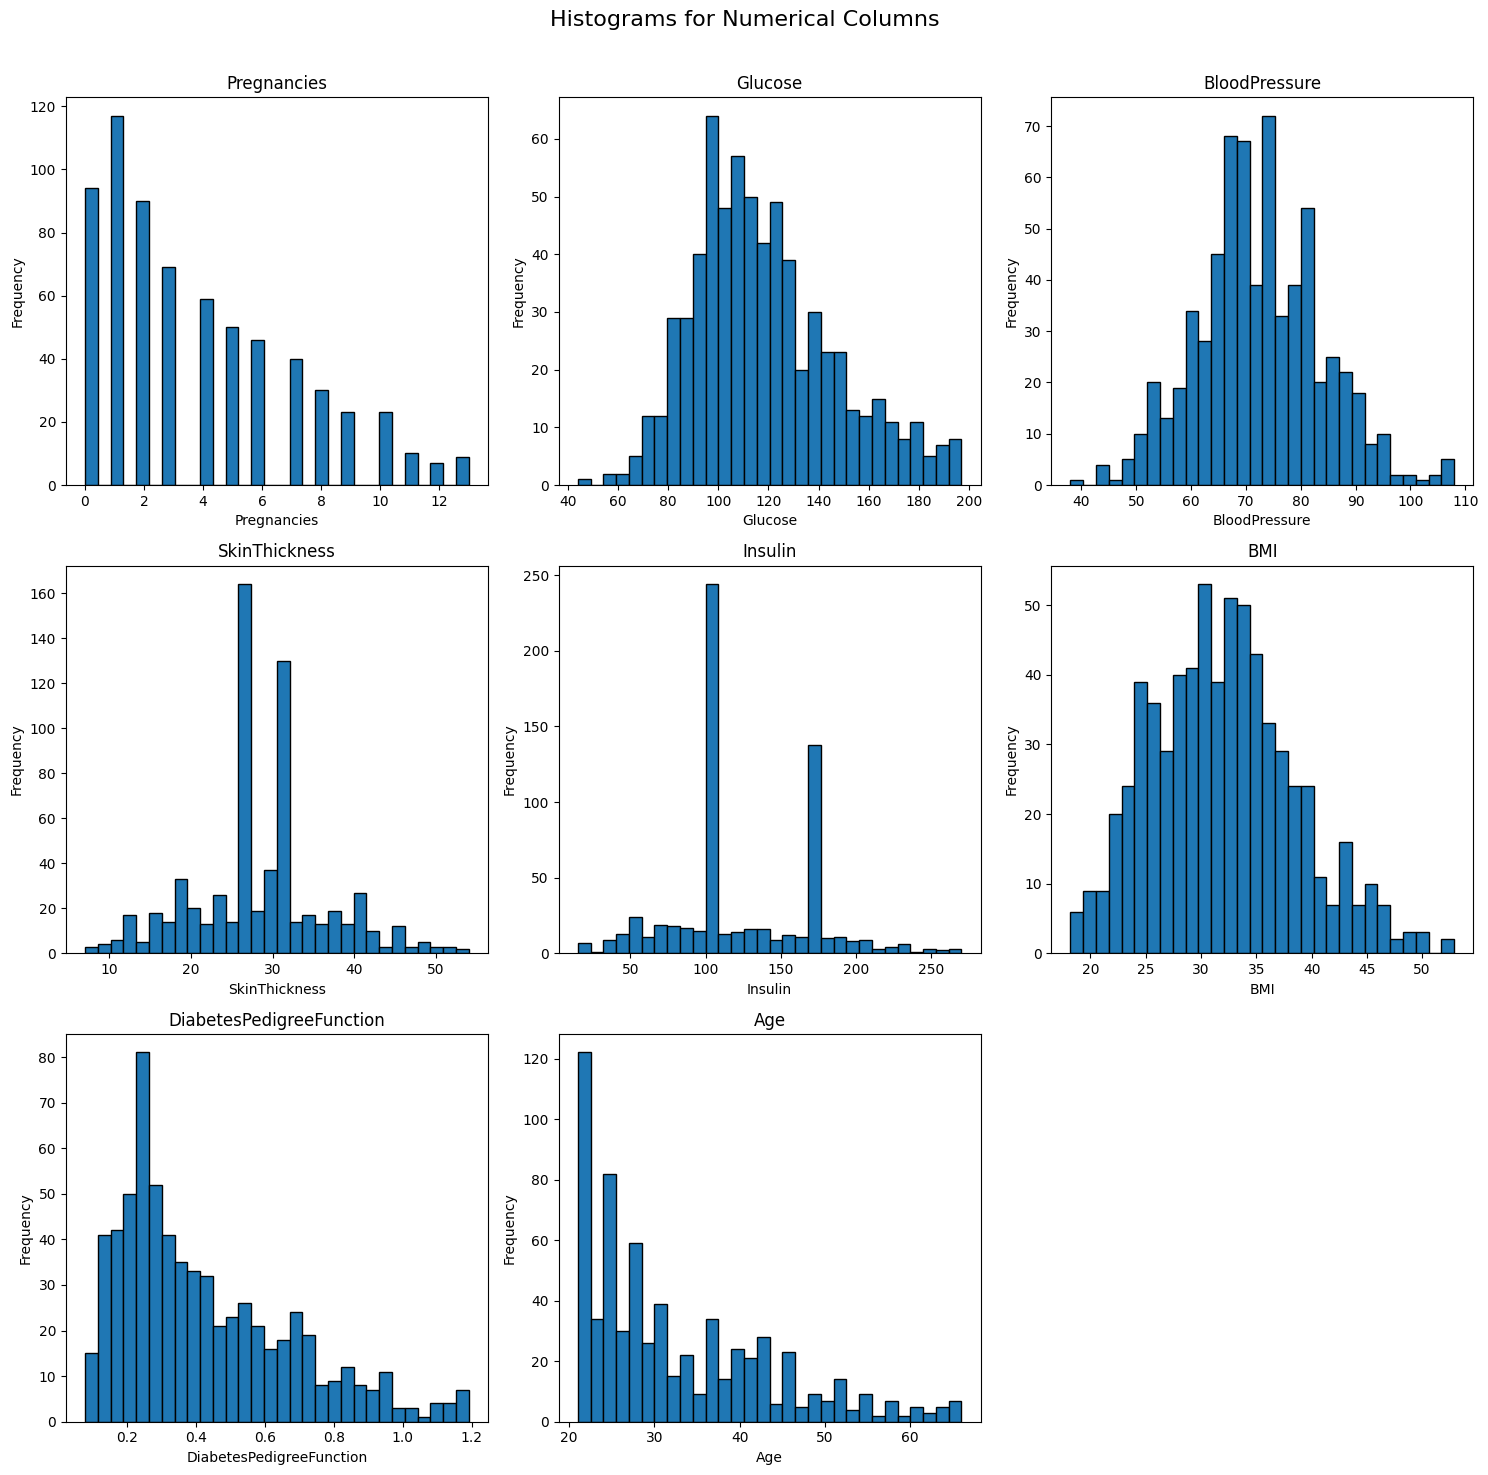

In [332]:
plot_histograms(df_no_outliers, X, title='Histograms for Numerical Columns')

# Pearson correlation heatmap

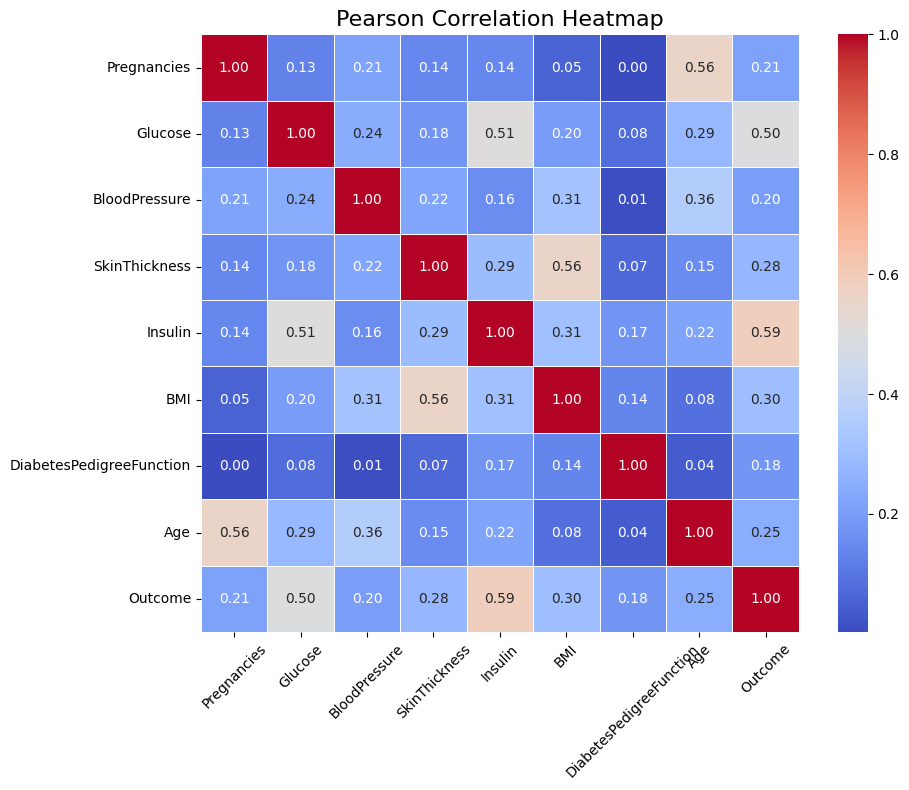

In [333]:
# Compute the Pearson correlation matrix
corr_matrix = df_no_outliers.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Train test split

In [334]:
from sklearn.model_selection import train_test_split

# Step 1: Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Step 2: Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Optional: Print shapes to confirm
print("🧪 Dataset split:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


🧪 Dataset split:
X_train: (533, 8), y_train: (533,)
X_test:  (134, 8), y_test:  (134,)


# SMOTE 

In [263]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and resample only the training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Optional: Check class distribution after SMOTE
print("✅ Class distribution after SMOTE:")
print(y_train_sm.value_counts())


✅ Class distribution after SMOTE:
Outcome
0    381
1    381
Name: count, dtype: int64


# Evaluate before FE

In [336]:
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Step 1: Apply MinMax scaling (-1 to 1) on original training set (before SMOTE)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Apply SMOTE on the scaled training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Step 3: Train the XGBoost model
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    random_state=42
)
model.fit(X_train_sm, y_train_sm)

# Step 3.1: Predict on the training set
y_train_pred = model.predict(X_train_sm)
y_train_proba = model.predict_proba(X_train_sm)[:, 1]

# Evaluate training performance
train_accuracy = accuracy_score(y_train_sm, y_train_pred)
train_precision = precision_score(y_train_sm, y_train_pred, zero_division=0)
train_recall = recall_score(y_train_sm, y_train_pred)
train_f1 = f1_score(y_train_sm, y_train_pred)
train_roc_auc = roc_auc_score(y_train_sm, y_train_proba)
train_conf_matrix = confusion_matrix(y_train_sm, y_train_pred)

# Print training metrics
print("\n📈 XGBoost Training Set Performance:")
print(f"Accuracy:  {train_accuracy:.3f}")
print(f"Precision: {train_precision:.3f}")
print(f"Recall:    {train_recall:.3f}")
print(f"F1 Score:  {train_f1:.3f}")
print(f"ROC AUC:   {train_roc_auc:.3f}")
print("\nConfusion Matrix (Train):")
print(train_conf_matrix)

# Step 4: Predict on the scaled test set
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Step 5: Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 6: Print results
print("📊 XGBoost Performance (after MinMax Scaling + SMOTE):")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:57:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📈 XGBoost Training Set Performance:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

Confusion Matrix (Train):
[[363   0]
 [  0 363]]
📊 XGBoost Performance (after MinMax Scaling + SMOTE):
Accuracy:  0.910
Precision: 0.897
Recall:    0.814
F1 Score:  0.854
ROC AUC:   0.959

Confusion Matrix:
[[87  4]
 [ 8 35]]


In [298]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import numpy as np

# Step 1: Define search space
search_space = [
    Integer(50, 300, name='n_estimators'),
    Real(0.01, 0.3, name='learning_rate'),
    Integer(3, 10, name='max_depth'),
    Real(0.5, 1.0, name='subsample'),
    Real(0.5, 1.0, name='colsample_bytree'),
    Real(1e-9, 10.0, name='reg_lambda')
]

# Step 2: Define the objective function
@use_named_args(search_space)
def objective(**params):
    model = xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        **params
    )
    # Use 5-fold CV to minimize the negative ROC AUC
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='accuracy')
    return -np.mean(scores)

# Step 3: Run Bayesian optimization
print("⏳ Running Bayesian Optimization...")
opt_result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=30,
    random_state=42
)

# Step 4: Extract best parameters
best_params = {
    'n_estimators': opt_result.x[0],
    'learning_rate': opt_result.x[1],
    'max_depth': opt_result.x[2],
    'subsample': opt_result.x[3],
    'colsample_bytree': opt_result.x[4],
    'reg_lambda': opt_result.x[5],
}

print("✅ Best Parameters Found:")
print(best_params)

# Step 5: Train final model with best hyperparameters
best_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    **best_params
)
best_model.fit(X_train_sm, y_train_sm)

# Step 5.1: Evaluate on training set to check for overfitting
y_train_pred = best_model.predict(X_train_sm)
y_train_proba = best_model.predict_proba(X_train_sm)[:, 1]

train_accuracy = accuracy_score(y_train_sm, y_train_pred)
train_precision = precision_score(y_train_sm, y_train_pred, zero_division=0)
train_recall = recall_score(y_train_sm, y_train_pred)
train_f1 = f1_score(y_train_sm, y_train_pred)
train_roc_auc = roc_auc_score(y_train_sm, y_train_proba)
train_conf_matrix = confusion_matrix(y_train_sm, y_train_pred)

# Print training results
print("📈 Training Set Performance:")
print(f"Accuracy:  {train_accuracy:.3f}")
print(f"Precision: {train_precision:.3f}")
print(f"Recall:    {train_recall:.3f}")
print(f"F1 Score:  {train_f1:.3f}")
print(f"ROC AUC:   {train_roc_auc:.3f}")
print("\nConfusion Matrix (Train):")
print(train_conf_matrix)

# Step 6: Evaluate on test set
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, zero_division=0)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, y_proba_best)
conf_matrix = confusion_matrix(y_test, y_pred_best)

# Step 7: Print results
print("\n📊 XGBoost (Bayesian Optimized) Performance:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)


⏳ Running Bayesian Optimization...


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

✅ Best Parameters Found:
{'n_estimators': 293, 'learning_rate': 0.3, 'max_depth': 10, 'subsample': 0.9014149749780699, 'colsample_bytree': 1.0, 'reg_lambda': 1e-09}


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📈 Training Set Performance:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC AUC:   1.000

Confusion Matrix (Train):
[[363   0]
 [  0 363]]

📊 XGBoost (Bayesian Optimized) Performance:
Accuracy:  0.896
Precision: 0.892
Recall:    0.767
F1 Score:  0.825
ROC AUC:   0.957

Confusion Matrix:
[[87  4]
 [10 33]]


## RF

In [337]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

# Step 1: MinMax Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Apply SMOTE on the scaled training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Step 3: Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_sm, y_train_sm)

# Step 4: Predict
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Step 5: Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Step 6: Print Results
print("🌲 Random Forest Performance (after MinMax Scaling + SMOTE):")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")
print(f"ROC AUC:   {roc_auc_rf:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)



🌲 Random Forest Performance (after MinMax Scaling + SMOTE):
Accuracy:  0.925
Precision: 0.902
Recall:    0.860
F1 Score:  0.881
ROC AUC:   0.941

Confusion Matrix:
[[87  4]
 [ 6 37]]


In [338]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Step 1: MinMax Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Apply SMOTE on the scaled training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Step 3: Define hyperparameter grid
rf_params = {
    'criterion': ['gini', 'entropy'],
    'n_estimators': list(range(50, 201, 50)),  # e.g., [50, 100, 150, 200]
    'max_depth': list(range(3, 11, 2))         # e.g., [3, 5, 7, 9]
}

# Step 4: Grid Search CV
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_sm, y_train_sm)

# Step 5: Use best model for prediction
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# Step 6: Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Step 7: Print Results
print("🌲 Random Forest Performance (GridSearch + SMOTE + MinMax Scaling):")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best Cross-Validation Score: {grid_rf.best_score_:.3f}")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")
print(f"ROC AUC:   {roc_auc_rf:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)


🌲 Random Forest Performance (GridSearch + SMOTE + MinMax Scaling):
Best Parameters: {'criterion': 'gini', 'max_depth': 9, 'n_estimators': 200}
Best Cross-Validation Score: 0.913
Accuracy:  0.925
Precision: 0.884
Recall:    0.884
F1 Score:  0.884
ROC AUC:   0.952

Confusion Matrix:
[[86  5]
 [ 5 38]]


# CatBoost

In [341]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Step 1: MinMax Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Step 3: Define CatBoost hyperparameter grid
cat_params = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

# Step 4: Grid Search with CatBoost
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

grid_cat = GridSearchCV(
    cat_model,
    param_grid=cat_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_cat.fit(X_train_sm, y_train_sm)

# Step 5: Use best model to predict
best_cat = grid_cat.best_estimator_
y_pred_cat = best_cat.predict(X_test_scaled)
y_proba_cat = best_cat.predict_proba(X_test_scaled)[:, 1]

# Step 6: Evaluation metrics
accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat, zero_division=0)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_proba_cat)
conf_matrix_cat = confusion_matrix(y_test, y_pred_cat)

# Step 7: Print results
print("🐱 CatBoost Classifier Performance (GridSearch + SMOTE + MinMax Scaling):")
print(f"Best Parameters: {grid_cat.best_params_}")
print(f"Best Cross-Validation Score: {grid_cat.best_score_:.3f}")
print(f"Accuracy:  {accuracy_cat:.3f}")
print(f"Precision: {precision_cat:.3f}")
print(f"Recall:    {recall_cat:.3f}")
print(f"F1 Score:  {f1_cat:.3f}")
print(f"ROC AUC:   {roc_auc_cat:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix_cat)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
6 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, us

🐱 CatBoost Classifier Performance (GridSearch + SMOTE + MinMax Scaling):
Best Parameters: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best Cross-Validation Score: 0.927
Accuracy:  0.918
Precision: 0.881
Recall:    0.860
F1 Score:  0.871
ROC AUC:   0.945

Confusion Matrix:
[[86  5]
 [ 6 37]]


# Feature engineering

## Glucose

In [188]:
# Step 1: Define the classification function
def classify_glucose(val):
    if val < 100:
        return "Normal"
    elif 100 <= val < 126:
        return "Prediabetes"
    else:
        return "Diabetes"

## Blood pressure

In [189]:
# Step 1: Define classification function
def classify_bp(bp):
    if bp < 80:
        return "Normal"
    elif 80 <= bp < 90:
        return "Hypertension_Stage_1"
    else:
        return "Hypertension_Stage_2"

## Insulin

In [190]:
# Step 1: Define classification function
def classify_insulin(insulin):
    if insulin <= 16:
        return "Low"
    elif 16 < insulin <= 166:
        return "Normal"
    else:
        return "High"


## BMI

In [191]:
# Step 1: Define the classification function
def classify_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi <= 24.9:
        return "Healthy"
    elif 25.0 <= bmi <= 29.9:
        return "Overweight"
    else:
        return "Obese"


In [192]:
# Step 2: Apply feature engineering to both X_train_sm and X_test
def apply_feature_engineering(df):
    df = df.copy()

    # Glucose classification
    df["Glucose_Class"] = df["Glucose"].apply(classify_glucose)

    # Blood Pressure classification
    df["BloodPressure_Class"] = df["BloodPressure"].apply(classify_bp)

    # Insulin classification
    df["Insulin_Class"] = df["Insulin"].apply(classify_insulin)

    # BMI classification
    df["BMI_Class"] = df["BMI"].apply(classify_bmi)

    # One-hot encode the newly created class columns
    df = pd.get_dummies(df, columns=[
        "Glucose_Class", 
        "BloodPressure_Class", 
        "Insulin_Class", 
        "BMI_Class"
    ], prefix_sep="_")

    return df

# Step 3: Apply to both training and test sets
X_train_fe = apply_feature_engineering(X_train_sm)
X_test_fe = apply_feature_engineering(X_test)


In [193]:
X_train_fe

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_Class_Diabetes,Glucose_Class_Normal,...,BloodPressure_Class_Hypertension_Stage_1,BloodPressure_Class_Hypertension_Stage_2,BloodPressure_Class_Normal,Insulin_Class_High,Insulin_Class_Low,Insulin_Class_Normal,BMI_Class_Healthy,BMI_Class_Obese,BMI_Class_Overweight,BMI_Class_Underweight
0,1,106.000000,70.000000,28.000000,135.00000,34.200000,0.142000,22,False,False,...,False,False,True,False,False,True,False,True,False,False
1,3,174.000000,58.000000,22.000000,194.00000,32.900000,0.593000,36,True,False,...,False,False,True,True,False,False,False,True,False,False
2,5,189.000000,64.000000,33.000000,325.00000,31.200000,0.583000,29,True,False,...,False,False,True,True,False,False,False,True,False,False
3,0,91.000000,68.000000,32.000000,210.00000,39.900000,0.381000,25,False,True,...,False,False,True,True,False,False,False,True,False,False
4,9,184.000000,85.000000,15.000000,169.50000,30.000000,1.213000,49,True,False,...,True,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,4,109.000000,63.780011,43.670016,102.29984,34.909995,0.861992,25,False,False,...,False,False,True,False,False,True,False,True,False,False
758,2,136.365966,71.520978,32.000000,169.50000,29.271795,0.616021,24,True,False,...,False,False,True,True,False,False,False,False,True,False
759,1,146.000000,72.809877,32.000000,169.50000,31.406063,0.275305,28,True,False,...,False,False,True,True,False,False,False,True,False,False
760,8,184.939819,84.342126,16.597693,169.50000,29.389117,1.111124,49,True,False,...,True,False,False,True,False,False,False,False,True,False


In [194]:
X_test_fe

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_Class_Diabetes,Glucose_Class_Normal,Glucose_Class_Prediabetes,BloodPressure_Class_Hypertension_Stage_1,BloodPressure_Class_Hypertension_Stage_2,BloodPressure_Class_Normal,Insulin_Class_High,Insulin_Class_Normal,BMI_Class_Healthy,BMI_Class_Obese,BMI_Class_Overweight
629,8,91.0,82.0,27.0,102.5,35.6,0.587,68,False,True,False,True,False,False,False,True,False,True,False
262,7,161.0,86.0,32.0,169.5,30.4,0.165,47,True,False,False,True,False,False,True,False,False,True,False
344,3,81.0,86.0,16.0,66.0,27.5,0.306,22,False,True,False,True,False,False,False,True,False,False,True
618,1,199.0,76.0,43.0,169.5,42.9,1.394,22,True,False,False,False,False,True,True,False,False,True,False
335,1,196.0,76.0,36.0,249.0,36.5,0.875,29,True,False,False,False,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,0,95.0,80.0,45.0,92.0,36.5,0.330,26,False,True,False,True,False,False,False,True,False,True,False
418,0,120.0,74.0,18.0,63.0,30.5,0.285,26,False,False,True,False,False,True,False,True,False,True,False
691,1,102.0,74.0,32.0,169.5,39.5,0.293,42,False,False,True,False,False,True,True,False,False,True,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,True,False,False,False,False,True,True,False,True,False,False


# Scaling

In [167]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Define which columns use which scaler
minmax_cols = ['Pregnancies']  # bounded
standard_cols = ['Glucose', 'BloodPressure', 'BMI']  # normally distributed
robust_cols = ['DiabetesPedigreeFunction', 'Age', 'SkinThickness', 'Insulin']  # skewed

# Function to scale features by type
def apply_scaling(X_train, X_test, minmax_cols, standard_cols, robust_cols):
    # Initialize scalers
    mm_scaler = MinMaxScaler(feature_range=(-1, 1))
    std_scaler = StandardScaler()
    rb_scaler = RobustScaler()

    # Create new DataFrames to hold scaled values
    X_train_scaled = pd.DataFrame(index=X_train.index)
    X_test_scaled = pd.DataFrame(index=X_test.index)

    # Apply MinMaxScaler
    X_train_scaled[minmax_cols] = mm_scaler.fit_transform(X_train[minmax_cols])
    X_test_scaled[minmax_cols] = mm_scaler.transform(X_test[minmax_cols])

    # Apply StandardScaler
    X_train_scaled[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
    X_test_scaled[standard_cols] = std_scaler.transform(X_test[standard_cols])

    # Apply RobustScaler
    X_train_scaled[robust_cols] = rb_scaler.fit_transform(X_train[robust_cols])
    X_test_scaled[robust_cols] = rb_scaler.transform(X_test[robust_cols])

    # Add back one-hot encoded columns (leave them unscaled)
    other_cols = [col for col in X_train.columns if col not in minmax_cols + standard_cols + robust_cols]
    X_train_scaled[other_cols] = X_train[other_cols]
    X_test_scaled[other_cols] = X_test[other_cols]

    return X_train_scaled, X_test_scaled

# Apply scaling
X_train_final, X_test_final = apply_scaling(X_train_fe, X_test_fe, minmax_cols, standard_cols, robust_cols)


In [168]:
X_train_final

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,SkinThickness,Insulin,Glucose_Class_Diabetes,Glucose_Class_Normal,...,BloodPressure_Class_Hypertension_Stage_1,BloodPressure_Class_Hypertension_Stage_2,BloodPressure_Class_Normal,Insulin_Class_High,Insulin_Class_Low,Insulin_Class_Normal,BMI_Class_Healthy,BMI_Class_Obese,BMI_Class_Overweight,BMI_Class_Underweight
0,-0.846154,-0.630041,-0.273881,0.232005,-0.671126,-0.470588,-0.530110,-0.158352,False,False,...,False,False,True,False,False,True,False,True,False,False
1,-0.538462,1.692121,-1.340006,0.027768,0.554290,0.352941,-1.730110,0.722245,True,False,...,False,False,True,True,False,False,False,True,False,False
2,-0.230769,2.204362,-0.806943,-0.239311,0.527119,-0.058824,0.469890,2.677469,True,False,...,False,False,True,True,False,False,False,True,False,False
3,-1.000000,-1.142282,-0.451568,1.127504,-0.021737,-0.294118,0.269890,0.961051,False,True,...,False,False,True,True,False,False,False,True,False,False
4,0.384615,2.033615,1.058776,-0.427837,2.238897,1.117647,-3.130110,0.356574,True,False,...,True,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,-0.384615,-0.527592,-0.826488,0.343548,1.285170,-0.294118,2.603893,-0.646414,False,False,...,False,False,True,False,False,True,False,True,False,False
758,-0.692308,0.406940,-0.138751,-0.542242,0.616840,-0.352941,0.269890,0.356574,True,False,...,False,False,True,True,False,False,False,False,True,False
759,-0.846154,0.735937,-0.024240,-0.206938,-0.308922,-0.117647,0.269890,0.356574,True,False,...,False,False,True,True,False,False,False,True,False,False
760,0.230769,2.065710,1.000328,-0.523810,1.962088,1.117647,-2.810572,0.356574,True,False,...,True,False,False,True,False,False,False,False,True,False


In [169]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize XGBoost model
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train_final, y_train_sm)

# Make predictions
y_pred = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print metrics
print("📊 XGBoost Performance:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)


📊 XGBoost Performance:
Accuracy:  0.882
Precision: 0.844
Recall:    0.792
F1 Score:  0.817
ROC AUC:   0.941

Confusion Matrix:
[[89  7]
 [10 38]]


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:02:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_final, y_train_sm)

# Make predictions
y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

# Evaluate performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Print metrics
print("🌲 Random Forest Performance:")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")
print(f"ROC AUC:   {roc_auc_rf:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)


🌲 Random Forest Performance:
Accuracy:  0.868
Precision: 0.822
Recall:    0.771
F1 Score:  0.796
ROC AUC:   0.944

Confusion Matrix:
[[88  8]
 [11 37]]


# 5 Stratified Fold CV
split first <br>
scale <br>
smote on train set (hence got 5 different models for each smote-ed train set)

## min max scale for all columns

In [75]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE  # optional
import xgboost as xgb
import numpy as np
import pandas as pd

# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Loop over folds
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply MinMax scaling to training set
    scaler = MinMaxScaler(feature_range=(-1,1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Optional: apply SMOTE on training set
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

    # Train XGBoost classifier
    model = xgb.XGBClassifier(
        use_label_encoder=False, 
        eval_metric='logloss', 
        n_estimators=50, 
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# Final average results
print("📊 Average Metrics Across 5 Folds:")
for metric, values in metrics.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# Optional: print confusion matrices per fold
for i, cm in enumerate(metrics["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

📊 Average Metrics Across 5 Folds:
Accuracy: 0.740 ± 0.028
Precision: 0.612 ± 0.045
Recall: 0.632 ± 0.048
F1: 0.621 ± 0.039
Roc_auc: 0.795 ± 0.030

Confusion Matrix - Fold 1:
[[78 17]
 [15 34]]

Confusion Matrix - Fold 2:
[[74 21]
 [20 29]]

Confusion Matrix - Fold 3:
[[78 18]
 [21 27]]

Confusion Matrix - Fold 4:
[[70 26]
 [16 32]]

Confusion Matrix - Fold 5:
[[79 16]
 [17 31]]


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### RF

In [76]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics_rf = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Cross-validation loop
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Min-Max Scaling (fit on training, transform both)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = rf_model.predict(X_test_scaled)
    y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    metrics_rf["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics_rf["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics_rf["recall"].append(recall_score(y_test, y_pred))
    metrics_rf["f1"].append(f1_score(y_test, y_pred))
    metrics_rf["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics_rf["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# 📊 Print final averaged results
print("📊 Random Forest - Average Metrics Across 5 Folds:")
for metric, values in metrics_rf.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# Optional: print confusion matrices
for i, cm in enumerate(metrics_rf["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")


📊 Random Forest - Average Metrics Across 5 Folds:
Accuracy: 0.775 ± 0.026
Precision: 0.694 ± 0.050
Recall: 0.595 ± 0.051
F1: 0.639 ± 0.043
Roc_auc: 0.833 ± 0.026

Confusion Matrix - Fold 1:
[[83 12]
 [15 34]]

Confusion Matrix - Fold 2:
[[83 12]
 [22 27]]

Confusion Matrix - Fold 3:
[[82 14]
 [21 27]]

Confusion Matrix - Fold 4:
[[79 17]
 [20 28]]

Confusion Matrix - Fold 5:
[[86  9]
 [20 28]]


## Standardscaler for all columns

In [77]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE  # optional
import xgboost as xgb
import numpy as np
import pandas as pd

# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Loop over folds
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply MinMax scaling to training set
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Optional: apply SMOTE on training set
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

    # Train XGBoost classifier
    model = xgb.XGBClassifier(
        use_label_encoder=False, 
        eval_metric='logloss', 
        n_estimators=50, 
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# Final average results
print("📊 Average Metrics Across 5 Folds:")
for metric, values in metrics.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# Optional: print confusion matrices per fold
for i, cm in enumerate(metrics["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

📊 Average Metrics Across 5 Folds:
Accuracy: 0.730 ± 0.035
Precision: 0.592 ± 0.049
Recall: 0.649 ± 0.061
F1: 0.618 ± 0.048
Roc_auc: 0.795 ± 0.031

Confusion Matrix - Fold 1:
[[76 19]
 [14 35]]

Confusion Matrix - Fold 2:
[[74 21]
 [20 29]]

Confusion Matrix - Fold 3:
[[76 20]
 [21 27]]

Confusion Matrix - Fold 4:
[[66 30]
 [16 32]]

Confusion Matrix - Fold 5:
[[76 19]
 [14 34]]


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## Mix of different scalers for different columns

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import numpy as np
import pandas as pd

# ---- Assume df_no_outliers is already defined ----
# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Define which columns use which scaler
minmax_cols = ['Pregnancies']  # bounded
standard_cols = ['Glucose', 'BloodPressure', 'BMI']  # normally distributed
robust_cols = ['DiabetesPedigreeFunction', 'Age', 'SkinThickness', 'Insulin']  # skewed

# Prepare Stratified 5-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Loop through CV folds
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale separately per group
    X_train_scaled = pd.DataFrame(index=X_train.index)
    X_test_scaled = pd.DataFrame(index=X_test.index)

    # Min-Max Scaling (-1 to 1)
    mm_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_scaled[minmax_cols] = mm_scaler.fit_transform(X_train[minmax_cols])
    X_test_scaled[minmax_cols] = mm_scaler.transform(X_test[minmax_cols])

    # Standard Scaling
    std_scaler = StandardScaler()
    X_train_scaled[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
    X_test_scaled[standard_cols] = std_scaler.transform(X_test[standard_cols])

    # Robust Scaling
    rb_scaler = RobustScaler()
    X_train_scaled[robust_cols] = rb_scaler.fit_transform(X_train[robust_cols])
    X_test_scaled[robust_cols] = rb_scaler.transform(X_test[robust_cols])

    # XGBoost Classifier
    model = xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=50,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Collect metrics
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# 📊 Final results
print("📊 Average Metrics Across 5 Folds:")
for metric, values in metrics.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# 🔍 Optional: print confusion matrices
for i, cm in enumerate(metrics["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

📊 Average Metrics Across 5 Folds:
Accuracy: 0.757 ± 0.030
Precision: 0.646 ± 0.044
Recall: 0.611 ± 0.069
F1: 0.627 ± 0.053
Roc_auc: 0.811 ± 0.027

Confusion Matrix - Fold 1:
[[81 14]
 [14 35]]

Confusion Matrix - Fold 2:
[[78 17]
 [22 27]]

Confusion Matrix - Fold 3:
[[82 14]
 [23 25]]

Confusion Matrix - Fold 4:
[[75 21]
 [18 30]]

Confusion Matrix - Fold 5:
[[80 15]
 [17 31]]


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### RF

In [79]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

# ---- Assume df_no_outliers is already defined ----
# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Define which columns use which scaler
minmax_cols = ['Pregnancies']  # bounded
standard_cols = ['Glucose', 'BloodPressure', 'BMI']  # normally distributed
robust_cols = ['DiabetesPedigreeFunction', 'Age', 'SkinThickness', 'Insulin']  # skewed

# Prepare Stratified 5-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Loop through CV folds
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale separately per group
    X_train_scaled = pd.DataFrame(index=X_train.index)
    X_test_scaled = pd.DataFrame(index=X_test.index)

    # Min-Max Scaling (-1 to 1)
    mm_scaler = MinMaxScaler()
    X_train_scaled[minmax_cols] = mm_scaler.fit_transform(X_train[minmax_cols])
    X_test_scaled[minmax_cols] = mm_scaler.transform(X_test[minmax_cols])

    # Standard Scaling
    std_scaler = StandardScaler()
    X_train_scaled[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
    X_test_scaled[standard_cols] = std_scaler.transform(X_test[standard_cols])

    # Robust Scaling
    rb_scaler = RobustScaler()
    X_train_scaled[robust_cols] = rb_scaler.fit_transform(X_train[robust_cols])
    X_test_scaled[robust_cols] = rb_scaler.transform(X_test[robust_cols])

    # 🔁 Train Random Forest Classifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Collect metrics
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# 📊 Final averaged results
print("📊 Random Forest - Average Metrics Across 5 Folds:")
for metric, values in metrics.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# 🔍 Optional: print confusion matrices
for i, cm in enumerate(metrics["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")


📊 Random Forest - Average Metrics Across 5 Folds:
Accuracy: 0.766 ± 0.022
Precision: 0.677 ± 0.039
Recall: 0.587 ± 0.052
F1: 0.627 ± 0.041
Roc_auc: 0.829 ± 0.021

Confusion Matrix - Fold 1:
[[84 11]
 [17 32]]

Confusion Matrix - Fold 2:
[[82 13]
 [23 26]]

Confusion Matrix - Fold 3:
[[81 15]
 [22 26]]

Confusion Matrix - Fold 4:
[[79 17]
 [17 31]]

Confusion Matrix - Fold 5:
[[83 12]
 [21 27]]


In [80]:
X_train_scaled

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,SkinThickness,Insulin
0,0.461538,0.942049,-0.035089,0.216620,0.731572,1.3125,0.835226,0.000000
1,0.076923,-1.157997,-0.570404,-0.847016,-0.036161,0.1250,-0.021917,0.000000
2,0.615385,2.108742,-0.748843,-1.348445,0.856745,0.1875,0.000000,0.000000
3,0.076923,-1.024661,-0.570404,-0.619094,-0.547983,-0.5000,-0.879060,-1.719309
4,0.384615,-0.124641,0.143349,-0.998964,-0.453408,0.0625,0.000000,0.000000
...,...,...,...,...,...,...,...,...
712,0.692308,1.675399,0.143349,1.796879,0.108484,0.8750,0.263797,0.000000
713,0.692308,-1.024661,-0.927281,-1.470003,-0.617524,0.2500,0.000000,0.000000
714,0.769231,-0.624652,0.321788,0.110256,-0.536857,2.1250,2.692369,0.683044
715,0.153846,0.075364,-0.213527,0.702853,-0.066759,-0.1250,-0.307631,0.000000


# Min-max scale

In [15]:
# Create a copy of the DataFrame to keep original safe
df_minmax_scaled = df_no_outliers.copy()

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the X columns
df_minmax_scaled[X] = scaler.fit_transform(df_minmax_scaled[X])


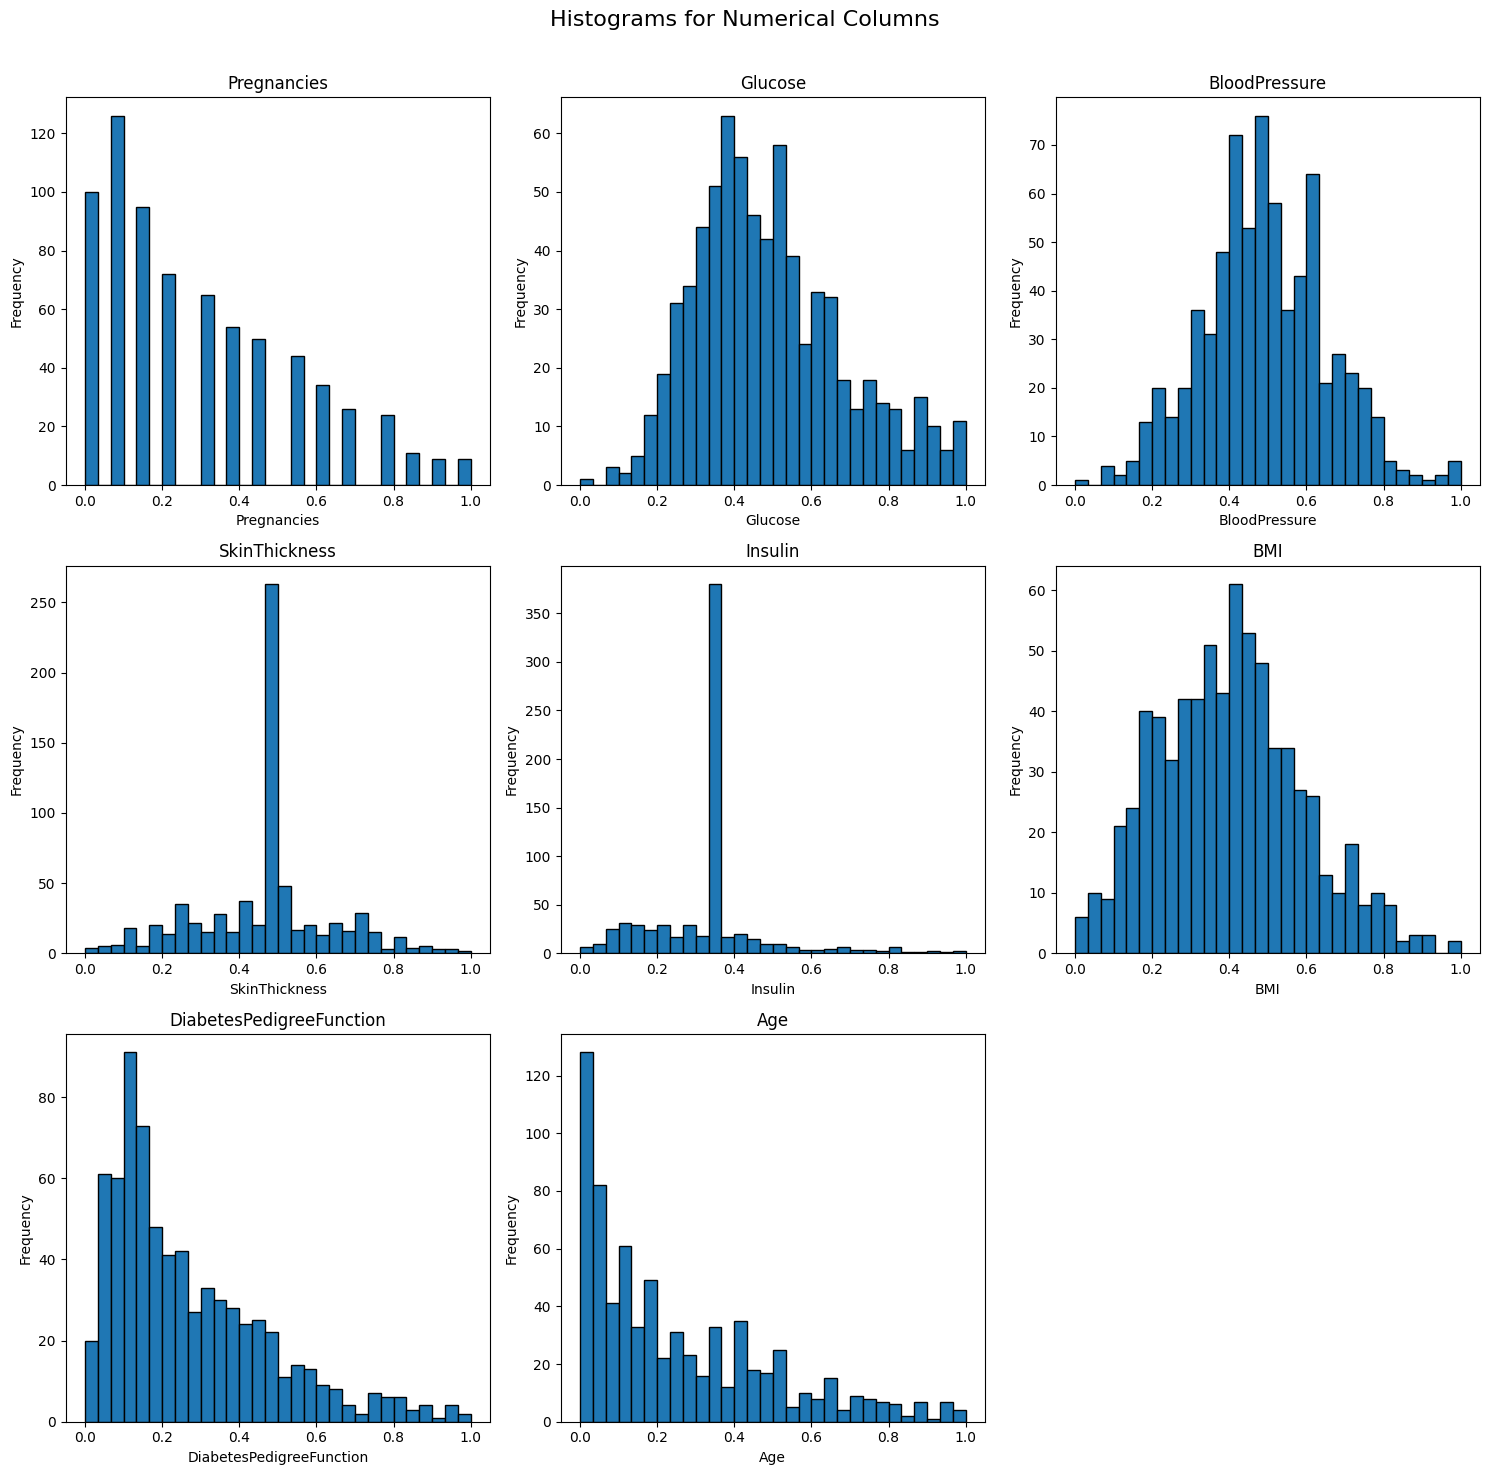

In [16]:
plot_histograms(df_minmax_scaled, X, title='Histograms for Numerical Columns')

# Standard scale

In [17]:
# Create a copy to keep the original safe
df_standard_scaled = df_no_outliers.copy()

# Choose columns to scale with StandardScaler
standard_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']  # all X columns

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
df_standard_scaled[standard_cols] = scaler.fit_transform(df_standard_scaled[standard_cols])

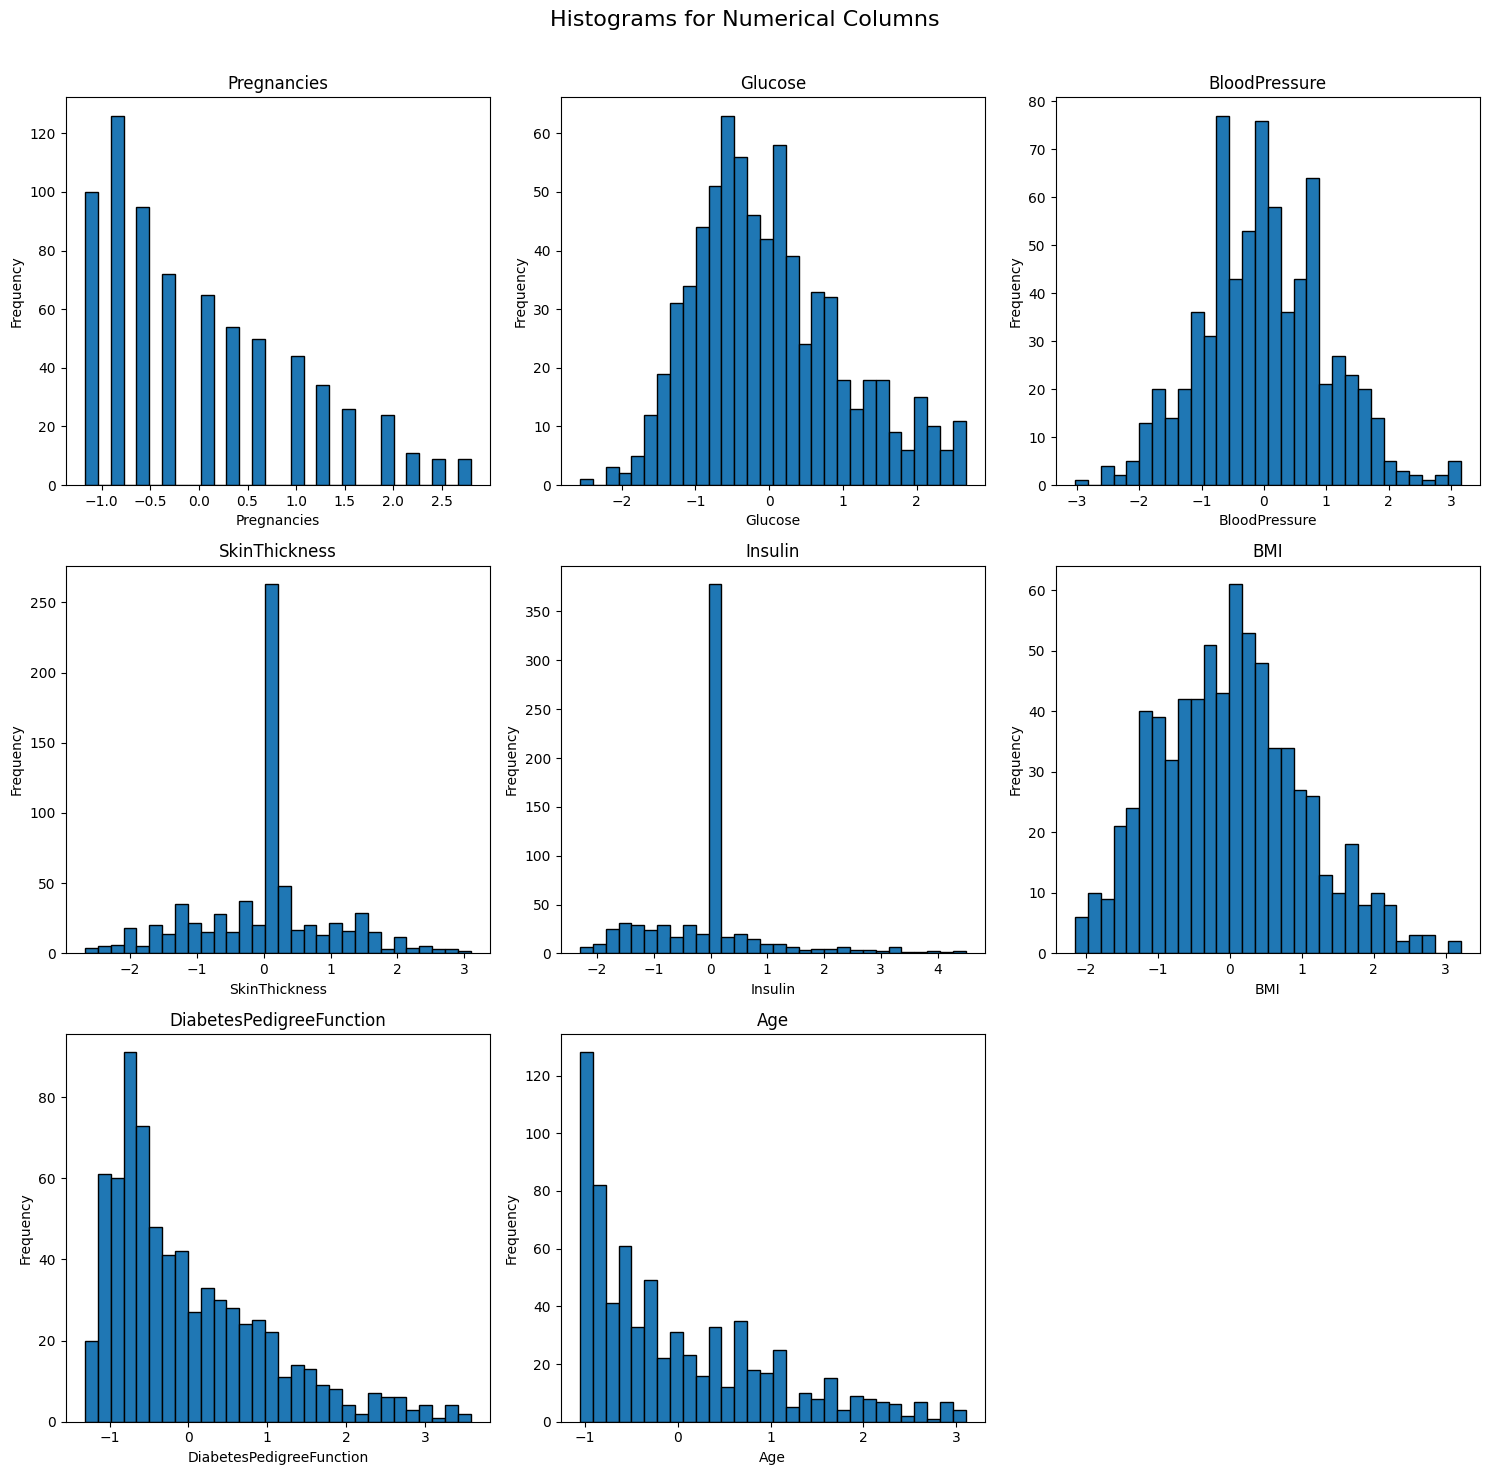

In [18]:
plot_histograms(df_standard_scaled, X, title='Histograms for Numerical Columns')

# Mix of scalers - respective to each column's distribution

# SMOTE - to handle class imbalance

In [32]:
# 1. Separate features and target
X_mm = df_minmax_scaled.drop(columns='Outcome')
y_mm = df_minmax_scaled['Outcome']

# 2. Train-test split (stratify to keep class ratio)
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X_mm, y_mm, test_size=0.2, stratify=y_mm, random_state=42
)

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_mm_sm, y_train_mm_sm = smote.fit_resample(X_train_mm, y_train_mm)

In [ ]:
# 1. Separate features and target
X = df_standard_scaled.drop(columns='Outcome')   # assuming 'Outcome' is your label
y = df_standard_scaled['Outcome']

# 2. Train-test split (stratify helps maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Now you can train your model on X_train_sm, y_train_sm


In [20]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Outcome
0    381
1    194
Name: count, dtype: int64
After SMOTE: Outcome
0    381
1    381
Name: count, dtype: int64


In [33]:
X_train_mm_sm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000
mean,0.311965,0.517740,0.500359,0.470048,0.344660,0.421883,0.274344,0.274955
std,0.252902,0.185703,0.160596,0.160785,0.133630,0.185354,0.204551,0.242357
min,0.000000,0.000000,0.085714,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.076923,0.380645,0.387168,0.422546,0.322997,0.291787,0.122921,0.079357
50%,0.245130,0.501205,0.491503,0.471349,0.363174,0.415867,0.211135,0.191489
75%,0.461538,0.632258,0.600000,0.531915,0.363174,0.530259,0.386793,0.425532
max,1.000000,0.987097,1.000000,1.000000,1.000000,1.000000,1.000000,0.978723


In [30]:
X_train_sm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000
mean,0.068869,0.143633,0.062114,0.043928,0.033582,0.108844,0.025038,0.088437
std,1.004804,0.973983,1.000728,0.933590,0.909072,1.000769,1.001769,1.001977
min,-1.172338,-2.567312,-2.499318,-2.671292,-2.301497,-2.154271,-1.313619,-1.054890
25%,-0.867156,-0.567083,-0.644069,-0.261360,-0.105760,-0.593345,-0.708509,-0.734756
50%,-0.139397,0.060614,0.010143,0.047173,0.167359,0.065246,-0.280331,-0.258554
75%,0.658750,0.747317,0.681109,0.396480,0.167359,0.708243,0.566292,0.714746
max,2.795019,2.597838,3.154774,3.096119,4.496505,3.208516,3.580341,3.015274


# Feature engineering